# Aula 06: Manipulação de Imagens como Dados (PIL + OpenCV)

Nesta seção vamos reproduzir os exemplos práticos do item **4. Mão na Massa** do material. Os notebooks permitem executar células interativas contendo código e explicações.

## Usando Pillow (PIL)

A biblioteca *Pillow* é ideal para operações simples de imagem. O código abaixo abre uma imagem, redimensiona, rotaciona, converte para escala de cinza e salva o resultado.

In [2]:
from PIL import Image

In [24]:
# 1. Abrir uma imagem
# (Certifique-se de ter uma imagem 'foto.jpg' na pasta ou troque o nome)
try:
    img = Image.open("zidane.jpg")
except FileNotFoundError:
    print("Imagem não encontrada! Coloque uma imagem 'foto.jpg' na pasta.")
    raise

print(f"Formato: {img.format}, Tamanho: {img.size}, Modo: {img.mode}")

Formato: JPEG, Tamanho: (1280, 720), Modo: RGB


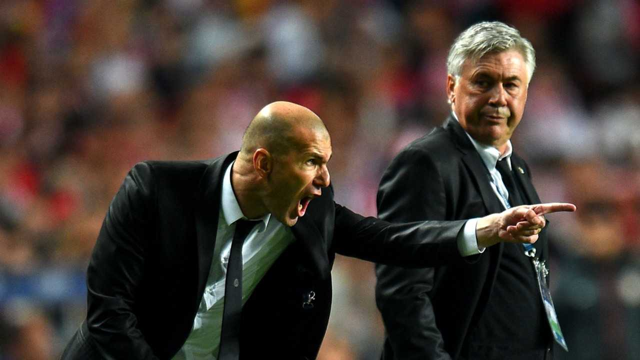

In [25]:
# 2. Redimensionar (Escala)
novo_tamanho = (img.width // 2, img.height // 2)
img_pequena = img.resize(novo_tamanho)
img_pequena.show()  # Abre no visualizador padrão do seu SO

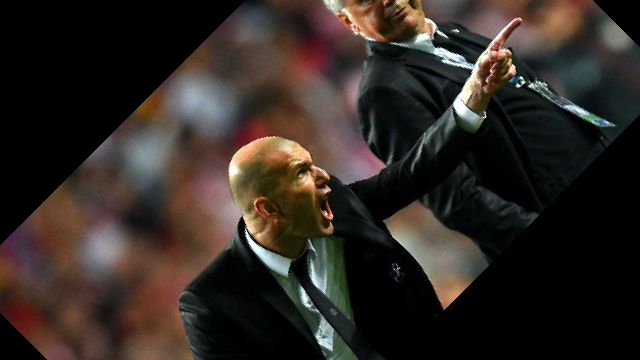

In [26]:
# 3. Rotacionar
img_rotacionada = img_pequena.rotate(45)  # 45 graus anti-horário
img_rotacionada.show()  # Abre no visualizador padrão do seu SO

In [27]:
# 4. Converter para Preto e Branco (Escala de Cinza)
img_pb = img_rotacionada.convert("L")

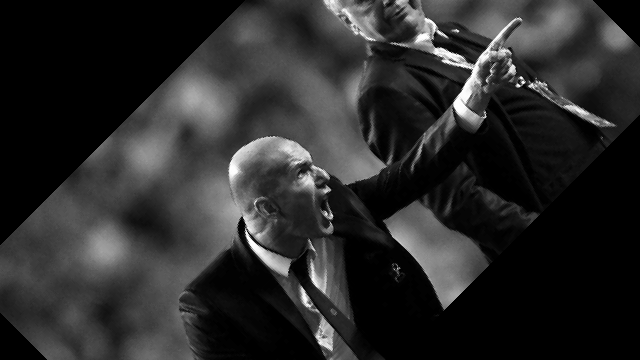

In [28]:
# 5. Salvar e Mostrar
img_pb.save("resultado_pil.png")
img_pb.show()  # Abre no visualizador padrão do seu SO

**Como rodar:** execute este notebook com o kernel do projeto (`aula-06 (poetry)`) ou salve o código num script e rode com `poetry run python`.

## Usando OpenCV

O OpenCV lê imagens no formato BGR por padrão. No exemplo a seguir lemos, redimensionamos, rotacionamos, convertemos para cinza e salvamos.

In [8]:
import cv2

In [29]:
# 1. Abrir imagem
img = cv2.imread("zidane.jpg")

if img is None:
    print("Erro ao abrir a imagem!")
    raise FileNotFoundError

# Mostra dimensões: (Altura, Largura, Canais)
print(f"Dimensões: {img.shape}")

Dimensões: (720, 1280, 3)


In [40]:
# 2. Redimensionar
nova_largura = int(img.shape[1] * 0.5)
nova_altura = int(img.shape[0] * 0.5)
img_pequena = cv2.resize(img, (nova_largura, nova_altura))
cv2.imshow("imagem pequena", img_pequena)     # abre janela do OpenCV
cv2.waitKey(0)                                # espera tecla
cv2.destroyAllWindows()   

In [41]:
# 3. Rotacionar (mais complexo que PIL)
centro = (nova_largura // 2, nova_altura // 2)
angulo = 45
escala_rotacao = 1.0
matriz_rotacao = cv2.getRotationMatrix2D(centro, angulo, escala_rotacao)
img_rotacionada = cv2.warpAffine(img_pequena, matriz_rotacao, (nova_largura, nova_altura))
cv2.imshow("imagem rotacionada", img_rotacionada)     # abre janela do OpenCV
cv2.waitKey(0)                                # espera tecla
cv2.destroyAllWindows()   

In [42]:
# 4. Converter para Escala de Cinza
img_cinza = cv2.cvtColor(img_rotacionada, cv2.COLOR_BGR2GRAY)
cv2.imshow("imagem em cinza", img_cinza)     # abre janela do OpenCV
cv2.waitKey(0)                                # espera tecla
cv2.destroyAllWindows()   


In [39]:
# 5. Salvar e Mostrar
cv2.imwrite("resultado_opencv.png", img_cinza)

True

Pronto! você agora tem um notebook completo cobrindo os exemplos práticos de PIL e OpenCV. Salve e execute conforme necessário.